# Imports

In [ ]:
#test
#test on VScodes

In [22]:
import torch
print(torch.__version__)

2.2.2


In [23]:
import numpy

In [24]:
#Installs on colab
def running_on_colab():
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False

if running_on_colab():
    print("Running on Colab. Installing dependencies...")
    !pip install -q atomai neuraloperator ipympl ipywidgets hoffmanstmpy

    from google.colab import output
    output.enable_custom_widget_manager()

    !git clone -b ayush_dev --single-branch https://github.com/gnganesh99/NN_Error.git
    %cd NN_Error

    print("Colab setup complete.")

In [25]:
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
import os
from scipy.ndimage import zoom


try:
    get_ipython().run_line_magic("matplotlib", "widget")
except (ValueError, RuntimeError):
    get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt


# Make package and notebook-local helper modules importable whether this starts in repo root or notebooks/
repo_root = Path.cwd() if (Path.cwd() / "src" / "nnerror").exists() else Path.cwd().parent.parent
src_root = str((repo_root / "src").resolve())
nb_root = str((repo_root / "notebooks"/"STM").resolve())
for import_root in (src_root, nb_root):
    if import_root not in sys.path:
        sys.path.insert(0, import_root)




from nnerror.networks import FNO_im2spec, CustomDecoder, im2spec
from nnerror.training_functions import err_estimation, train_model, predict_spectra, norm_0to1, predict_posterior, append_training_set
from nnerror.plot_functions import plot_only_training_loss, plot_training_loss, \
    plot_error_prediction, plot_spectra, plot_error_prediction_3d, plot_scale_slider, plot_latent_space, cluster_latent_space, plot_latent_distribution, plot_scale_specific_error_and_acquisition_maps
from nnerror.utils import append_multiscale_data, edges_zeroed_image, interpolated_center_crop, paired_images_spectra_1


In [26]:
from stm_utils import Sxm_Image
from CITS_Class import CITS_Analysis


# Get data

In [27]:
data_folder = r"data/large_area" if not running_on_colab() else r"notebooks/STM/data/large_area"

img_sxm = os.path.join(data_folder, "EnZn2As2017.sxm")
spectra_sxm = os.path.join(data_folder, "EuZn2As2003.3ds")
#Get the morphology image
full_image = Sxm_Image(img_sxm).image()
full_image = norm_0to1(full_image)

#Get the current spectra
cits_obj = CITS_Analysis(spectra_sxm)
hyperspectra = cits_obj.current

full_image.shape, hyperspectra.shape

File import successful.


((512, 512), (80, 250, 121))

In [28]:
WS = 32
WS_init = 4
d_WS = 4
n_epochs_im2spec = 5
n_epochs_error = 5
error_type = "L1" # "L1", "L2", or "cos"
append_image_type = 'pad' #pad, interpolate
model_type = 'im2spec'

(1024, 32, 32) (1024, 121) (1024, 2)
[30. 30.]


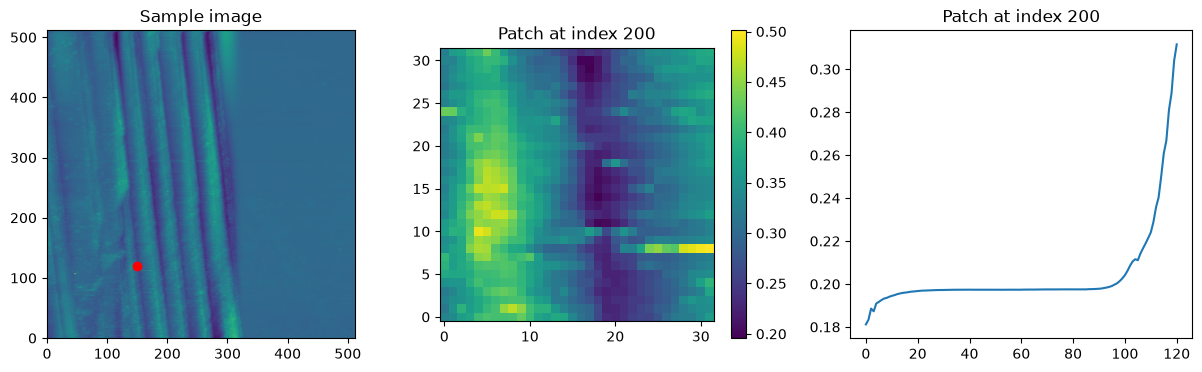

In [29]:


images, spectra, coordinates = paired_images_spectra_1(full_image, cits_obj, hyperspectra, window_size = WS,
                                                       coordinate_step = 15, image_norm=False, spectra_norm = False)

print(images.shape, spectra.shape, coordinates.shape)

print(coordinates[0])
fig, ax = plt.subplots(1, 3, figsize = (15, 4))


idx = 200

ax[0].imshow(full_image, origin = 'lower')
ax[0].scatter(coordinates[idx, 1], coordinates[idx, 0], c ="r")
ax[0].set_title("Sample image")


im = ax[1].imshow(images[idx], origin = 'lower')
fig.colorbar(im, ax=ax[1])
ax[1].set_title(f"Patch at index {idx}")
ax[2].plot(spectra[idx])
ax[2].set_title(f"Patch at index {idx}")

plt.show()

In [30]:
# coordinates are reversed.
swap_coordinates = coordinates.copy()
swap_coordinates = swap_coordinates[:, [1, 0]]
swap_coordinates.shape

(1024, 2)

## Train/test split

In [31]:
images_all = images.copy()
spectra_all = spectra.copy()
swap_coordinates_all = swap_coordinates.copy()

In [32]:
from sklearn.model_selection import train_test_split

images_train, images_test, spectra_train, spectra_test, s_coords_train, s_coords_test = train_test_split(
images_all, spectra_all, swap_coordinates_all, test_size = 0.2, random_state=42
)

initial_trainsize = images_train.shape[0]
print("images_train shape:", images_train.shape)
print("images_test shape:", images_test.shape)
print("spectra_train shape:", spectra_train.shape)
print("spectra_test shape:", spectra_test.shape)

images_train shape: (819, 32, 32)
images_test shape: (205, 32, 32)
spectra_train shape: (819, 121)
spectra_test shape: (205, 121)


## Augment across scales

In [33]:
images, spectra, scale_coordinates = append_multiscale_data(images_all, spectra_all, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=swap_coordinates_all,
                                                            append_image_type=append_image_type)

Augmented images shape: (8192, 32, 32), Augmented spectra shape: (8192, 121), Augmented coordinates shape: (8192, 3)


In [34]:
images_tr_aug, spectra_tr_aug, _ = append_multiscale_data(images_train, spectra_train, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=s_coords_train,
                                                            append_image_type=append_image_type)



images_test_aug, spectra_test_aug, _ = append_multiscale_data(images_test, spectra_test, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=s_coords_test,
                                                            append_image_type=append_image_type)

print("images_train shape:", images_tr_aug.shape)
print("images_test shape:", images_test_aug.shape)

Augmented images shape: (6552, 32, 32), Augmented spectra shape: (6552, 121), Augmented coordinates shape: (6552, 3)
Augmented images shape: (1640, 32, 32), Augmented spectra shape: (1640, 121), Augmented coordinates shape: (1640, 3)
images_train shape: (6552, 32, 32)
images_test shape: (1640, 32, 32)


## Model dimensions

In [35]:

print("images shape:", images.shape)
print("spectra shape:", spectra.shape)
in_dim = images[0].shape  # Input dimensions (image height and width)
out_dim = len(spectra[0])  # Output dimensions (spectra length)

images shape: (8192, 32, 32)
spectra shape: (8192, 121)


# Train im2spec

## IM2SPEC model

In [36]:
# ----------------------------
# 2) Fit FNO_im2spec model
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if model_type == 'FNO':

  # FNO_im2spec mode. Trains better with interpolation based augmentation.
  imspec_model = FNO_im2spec(
      target_size=out_dim,
      latent_dim=3,
      hidden_channels=32,
      n_modes=(16, 16),
      n_layers=4,
  ).to(device)

elif model_type == 'im2spec':

  # Use this normal im2spec. Augmentation by padding works better here.
  imspec_model = im2spec(feature_size=in_dim, target_size=out_dim, latent_dim=3).to(device)

else:
  raise ValueError(f"Unknown model type: {model_type}")


100%|██████████| 5/5 [06:50<00:00, 82.12s/it, train_loss=0.0025, val_loss=0.0040]

SWA triggered at epoch 4


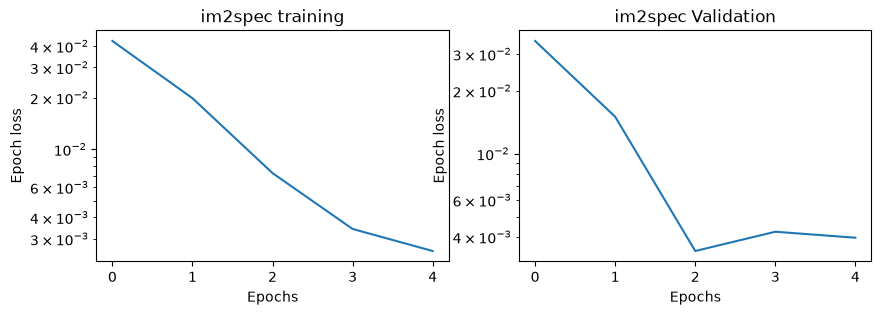

im2spec final train loss: 0.0025458371189112463
im2spec final internal val loss: 0.003959240890773279
im2spec held-out test loss: 0.014699677936732769


In [37]:


im2spec_training_dataset = TensorDataset(
    torch.tensor(images_tr_aug, dtype=torch.float32),
    torch.tensor(spectra_tr_aug, dtype=torch.float32),
)

im2spec_val_dataset = TensorDataset(
    torch.tensor(images_test_aug, dtype=torch.float32),
    torch.tensor(spectra_test_aug, dtype=torch.float32),
)

# train_model creates its own validation split from the dataset above.
# Keep images_test/spectra_test as an external held-out test set.

plot_im2spec_training = True

imspec_model, im2spec_train_loss, im2spec_val_loss = train_model(
    imspec_model,
    im2spec_training_dataset,
    n_batches=6,
    lr=1e-3,
    patience=10,
    n_epochs=n_epochs_im2spec,
    partial_train=False,
    val_dataset=im2spec_val_dataset,  # if not provided, train_model will split off its own validation set from the training dataset
    use_swa = True,
)

if plot_im2spec_training:
    plot_only_training_loss([im2spec_train_loss], [im2spec_val_loss])

imspec_model.eval()
with torch.no_grad():
    x_test = torch.tensor(images_test, dtype=torch.float32, device=device)
    y_test = torch.tensor(spectra_test, dtype=torch.float32, device=device)
    test_pred = imspec_model.predict(x_test)
    im2spec_test_loss = torch.nn.functional.mse_loss(test_pred, y_test).item()

print("im2spec final train loss:", im2spec_train_loss[-1])
print("im2spec final internal val loss:", im2spec_val_loss[-1])
print("im2spec held-out test loss:", im2spec_test_loss)


# Estimate error

In [38]:
# ----------------------------
# 3) Build error targets using err_estimation
# ----------------------------
error_mean, error_std, error_vector = err_estimation(imspec_model, images_tr_aug, spectra_tr_aug, error_type=error_type)
error_targets = error_mean.astype(np.float32).reshape(-1, 1)


print("error_mean shape:", error_mean.shape)
print("error_vector shape:", error_vector.shape)
print("error_targets shape:", error_targets.shape)


# ----------------------------
# 4) Fuse im2spec encoder with CustomDecoder
# ----------------------------
with torch.no_grad():
    latent_dim = imspec_model.encoder(torch.tensor(images[:1], dtype=torch.float32, device=device).unsqueeze(1)).shape[1]

error_model = CustomDecoder(encoder=imspec_model.encoder, embed_dim=latent_dim, target_size=1).to(device)

error_mean shape: (6552,)
error_vector shape: (6552, 121)
error_targets shape: (6552, 1)


## Train error model

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [04:04<00:00, 48.99s/it, train_loss=0.0119, val_loss=0.0135]


error model final train loss: 0.011904561626059669
error model final val loss: 0.013469010325414794


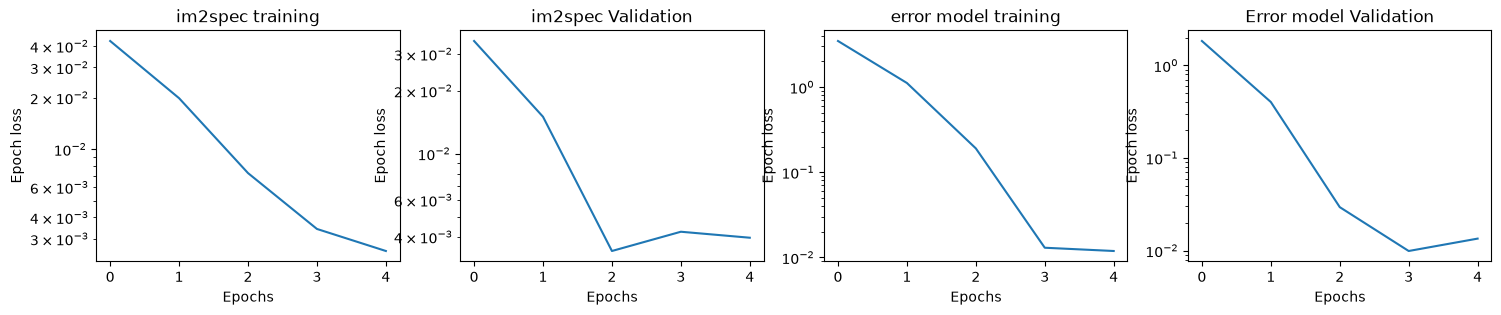

In [39]:

# ----------------------------
# 5) Train error model on images and estimated errors
# ----------------------------



error_training_dataset = TensorDataset(
    torch.tensor(images_tr_aug, dtype=torch.float32),
    torch.tensor(error_targets, dtype=torch.float32),
)


error_model, error_train_loss, error_val_loss = train_model(
    error_model,
    error_training_dataset,
    n_batches=6,
    lr=1e-3,
    patience=10,
    n_epochs=n_epochs_error,
    partial_train=True,
)

print("error model final train loss:", error_train_loss[-1])
print("error model final val loss:", error_val_loss[-1])

plot_training_loss([im2spec_train_loss], [im2spec_val_loss], error_train_loss, error_val_loss)

# Predict all errors

In [40]:
#Predict errors on the entire dataset using the trained error model
predicted_errors = predict_spectra(error_model, images, ensemble=False)
predicted_errors = np.clip(predicted_errors, 0, None)
print("predicted_errors shape:", np.asarray(predicted_errors).shape)
print("predicted_errors range:", float(np.min(predicted_errors)), float(np.max(predicted_errors)))

predicted_errors shape: (8192,)
predicted_errors range: 0.0 0.16625963151454926


## Acquisition function

In [41]:
from nnerror.training_functions import distance_acq_fn
from nnerror.plot_functions import plot_error_prediction, plot_spectra


#beta=0 is explotation. aq_fn is inverse to errors
aq_ind, aq_fn = distance_acq_fn(predicted_errors, beta = 0, lambda_ = 1, sample_next_points = 1, exclude_indices = [])
print(aq_fn.shape)


(8192,)


# Visualize acquisition results

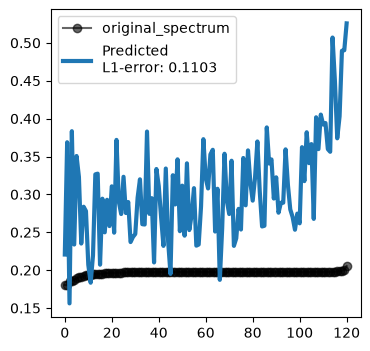

In [42]:
for ind in aq_ind:

    # Acquisition point
    next_coordinate = scale_coordinates[ind]
    predicted_spectra = predict_spectra(imspec_model, images[ind:ind+1], ensemble = False)

    spectral_error, _, _ = err_estimation(imspec_model, images[ind:ind+1], spectra[ind:ind+1], error_type=error_type)
    # error_log.append(spectral_error.mean())
    plot_spectra([predicted_spectra], spectra[ind], spectral_error.mean())

## 3D error and acquisition view

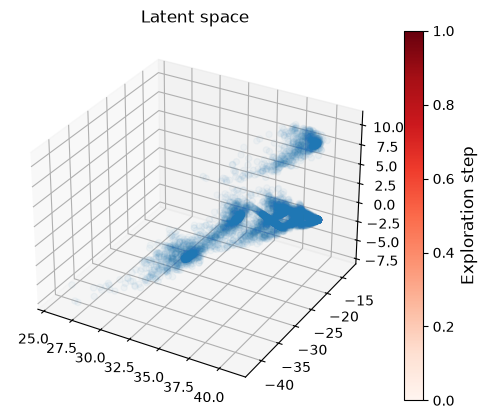

In [43]:
output_type = 'latent'
posterior_spectra = predict_posterior(imspec_model, images, output_type = output_type)
posterior_trainset = predict_posterior(imspec_model, images_train, output_type = output_type)
plot_latent_space(posterior_spectra, posterior_trainset[initial_trainsize:],lat_order = [0, 1, 2])

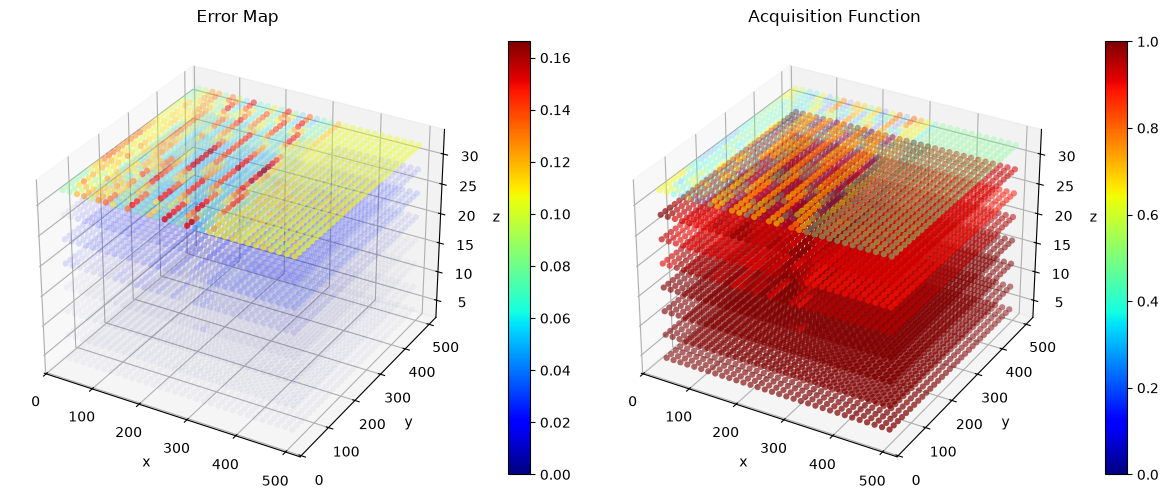

In [44]:
plot_error_prediction_3d(predicted_errors, aq_fn, scale_coordinates, aq_ind, alpha_scale=True,
                         colormap="jet", )

In [45]:
plot_scale_slider(scale_coordinates, predicted_errors, aq_fn, colormap="jet")

interactive(children=(IntSlider(value=0, continuous_update=False, description='Scale', max=7), Output()), _dom…

<function nnerror.plot_functions.plot_scale_slider.<locals>._draw_by_index(scale_index)>

In [46]:
#cluster_latent_space(posterior_spectra, lat_order = [0, 1, 2],  n_clusters = 3) # keep n_clusters < 5

## Scale-specific error maps

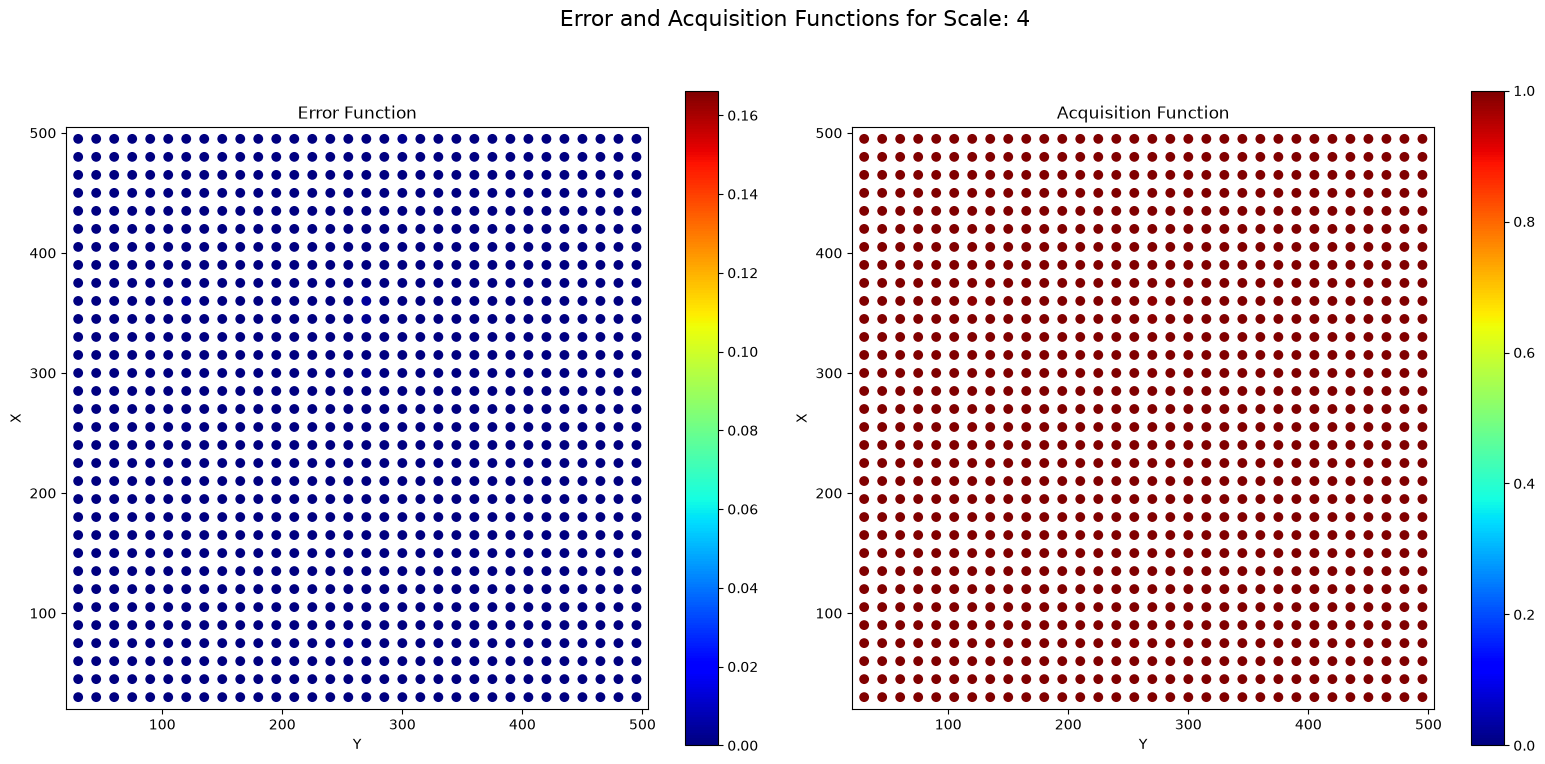

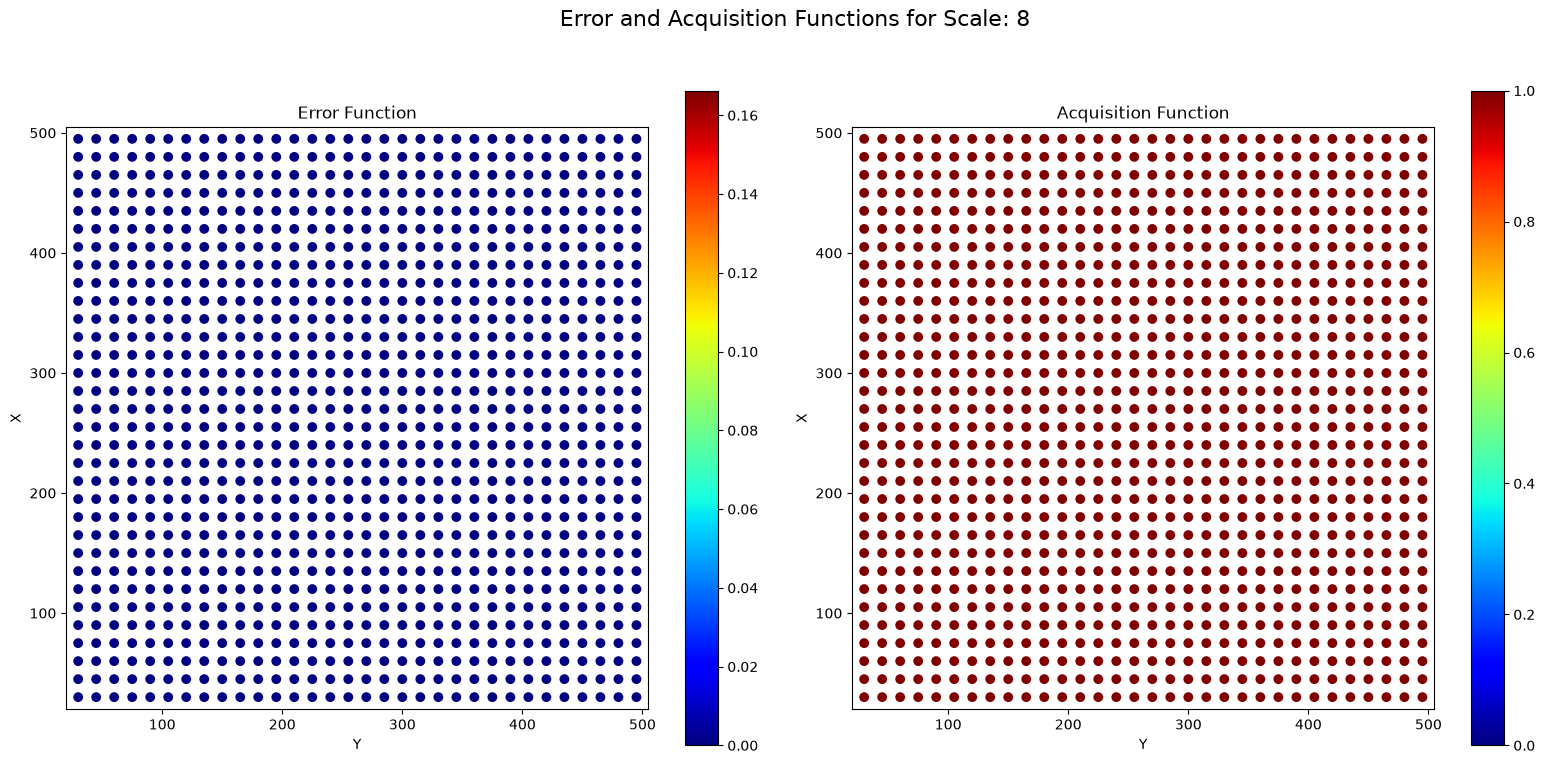

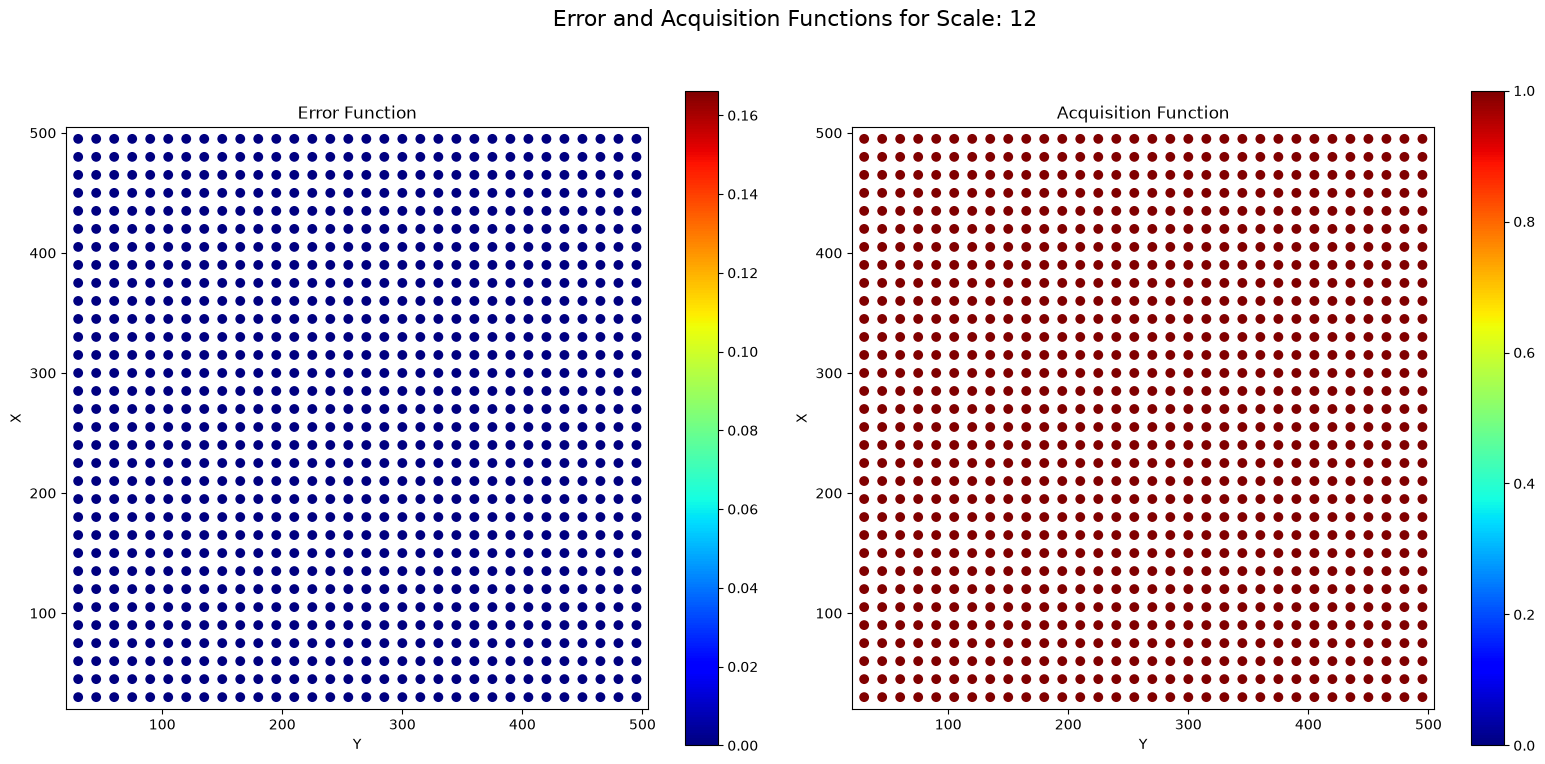

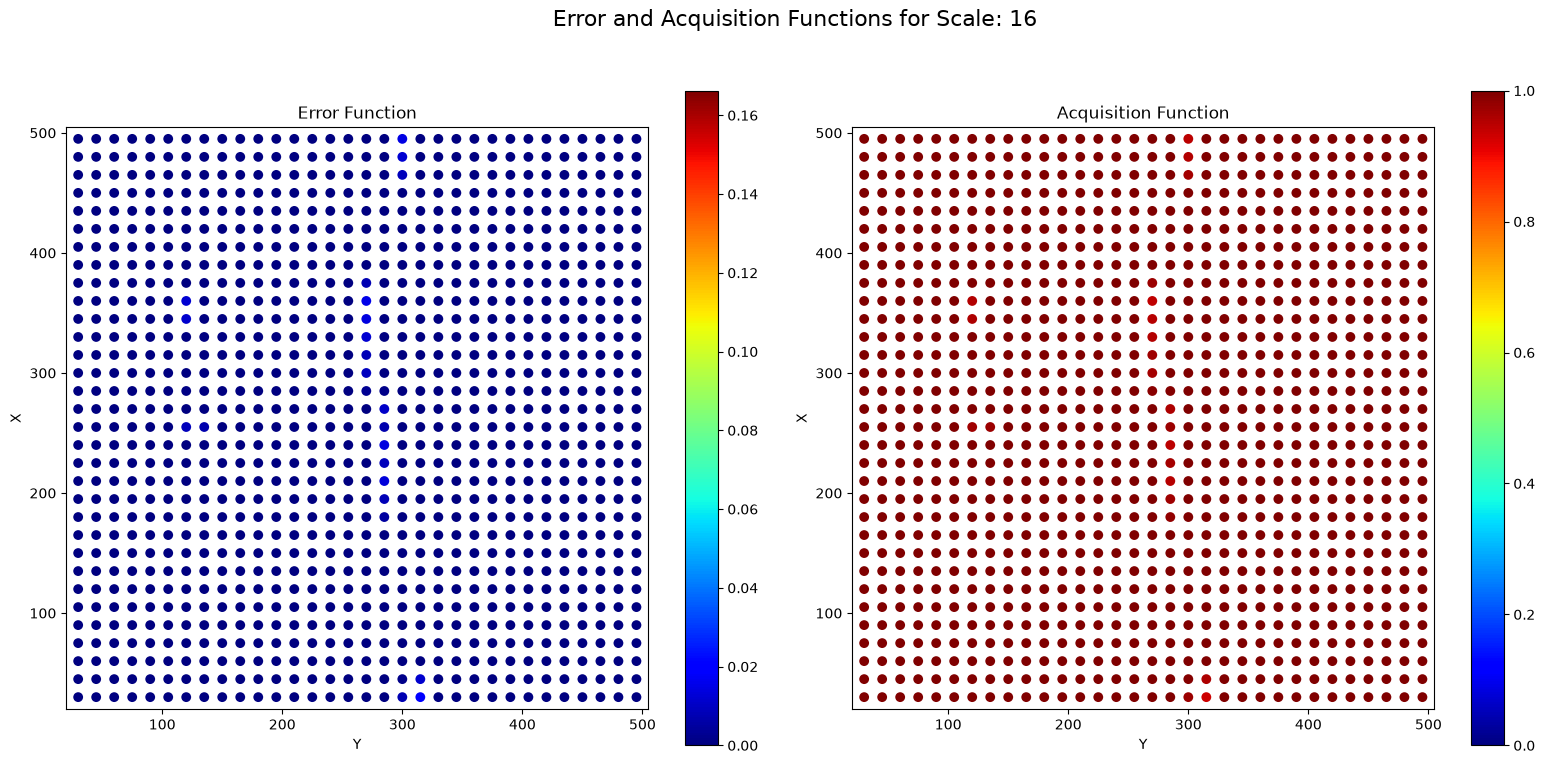

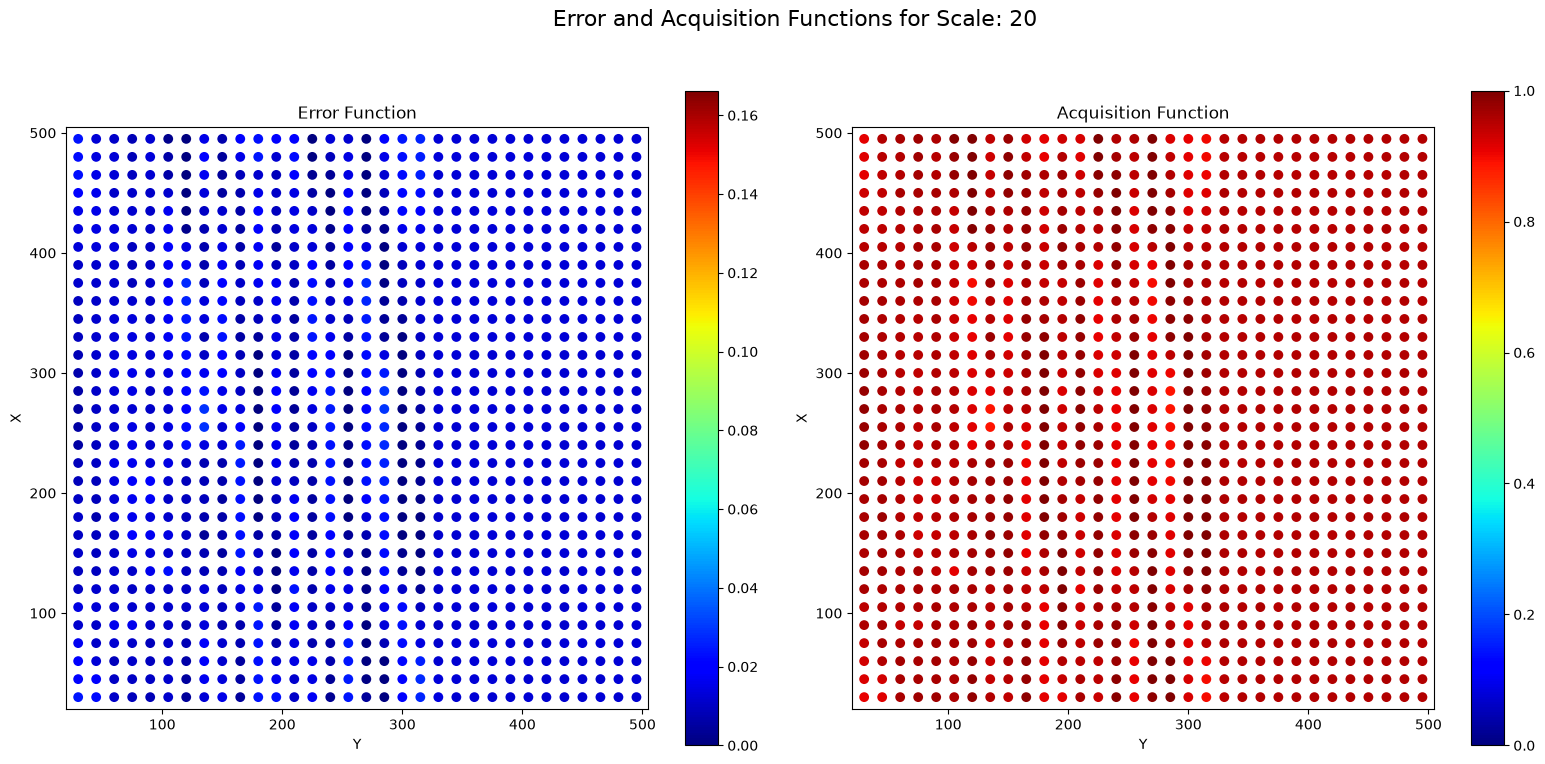

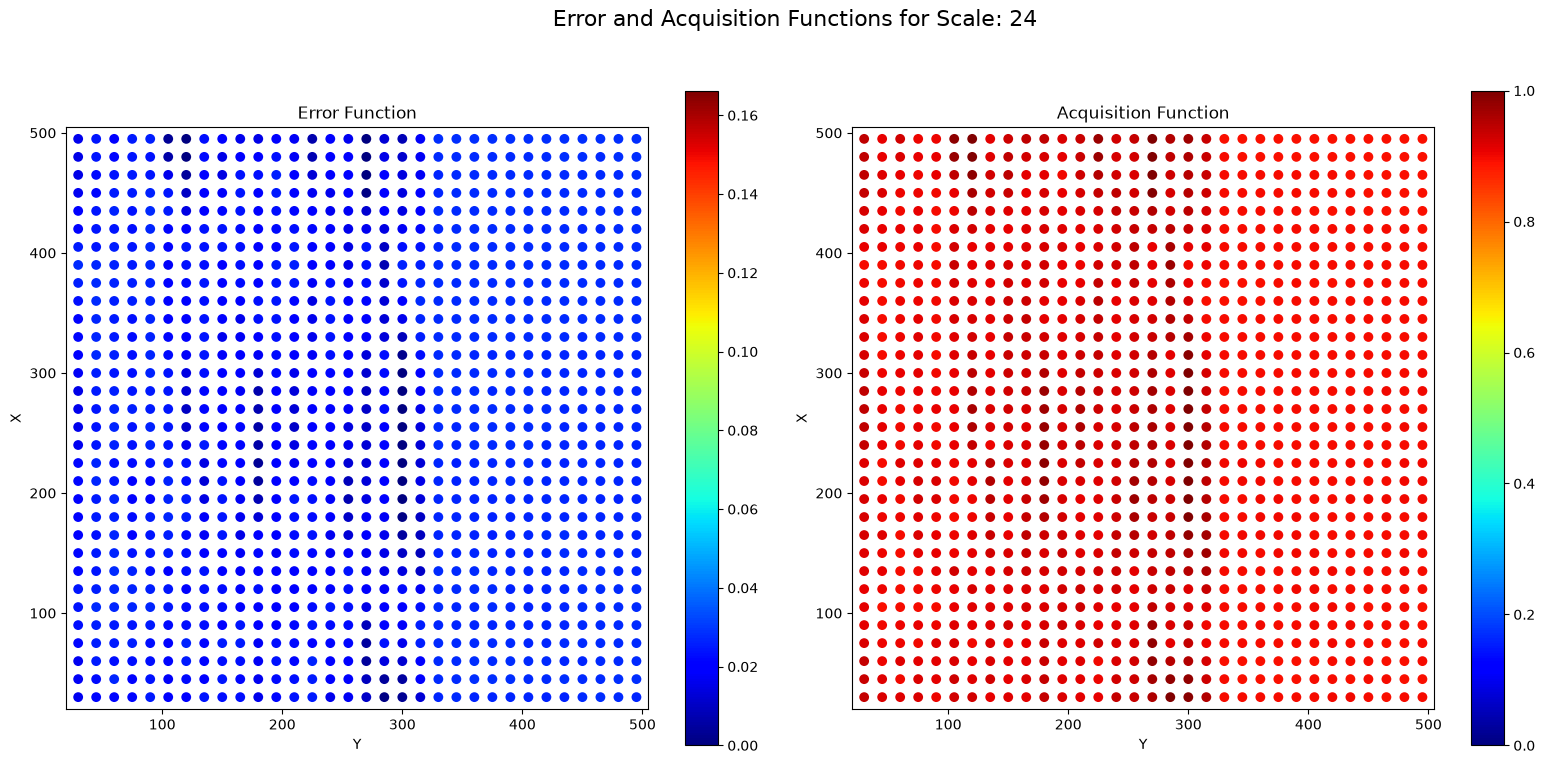

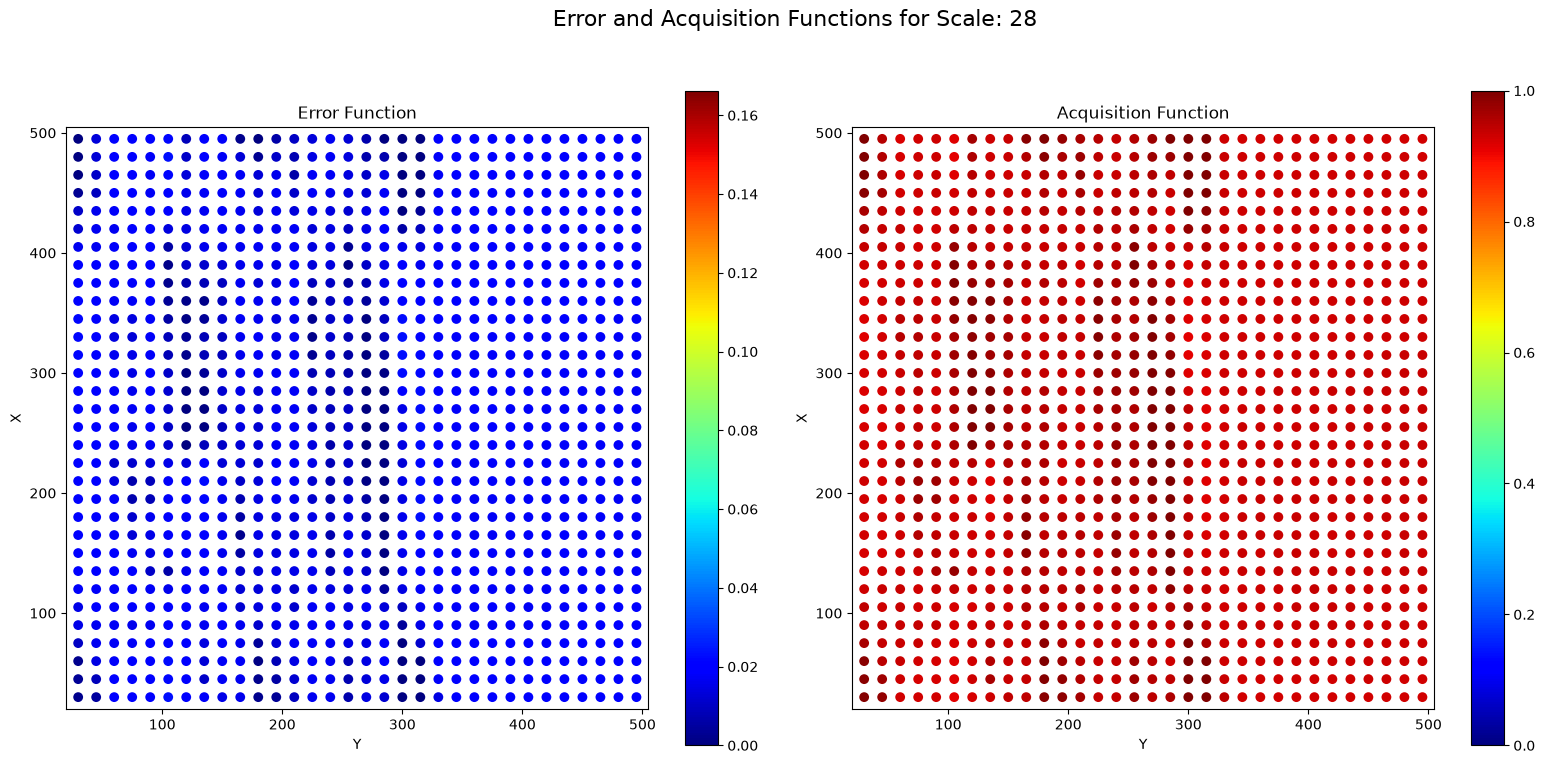

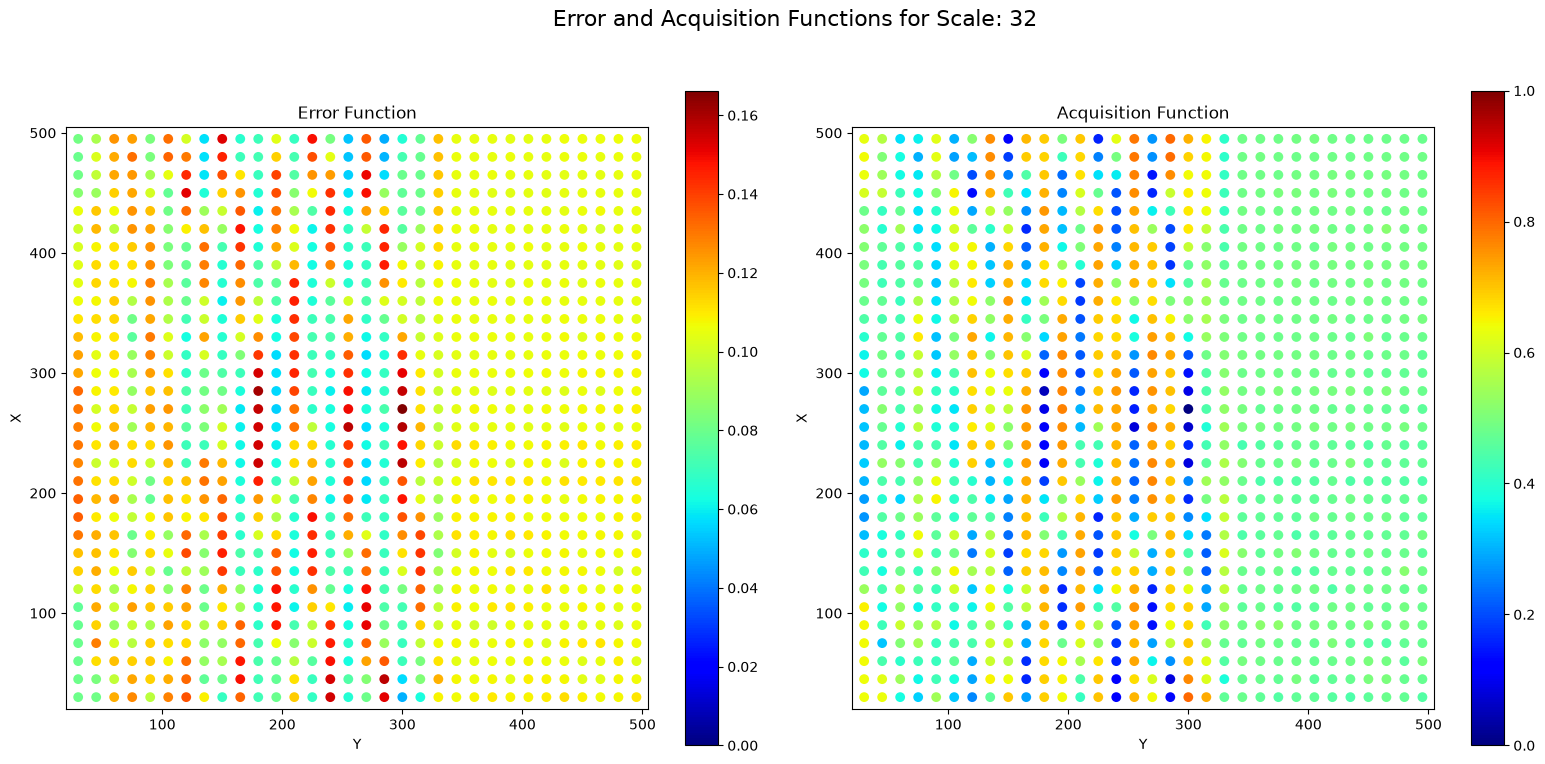

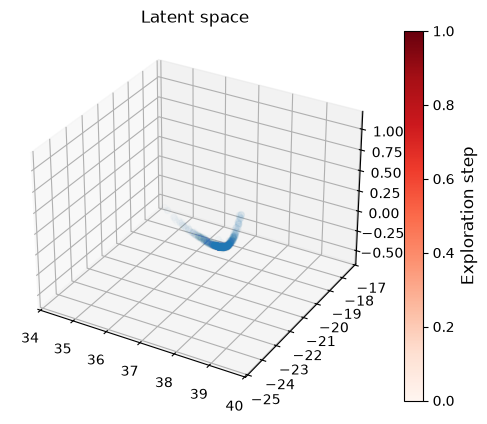

/Users/8ij/nnerror/NN_Error/.venv/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


(1024,)


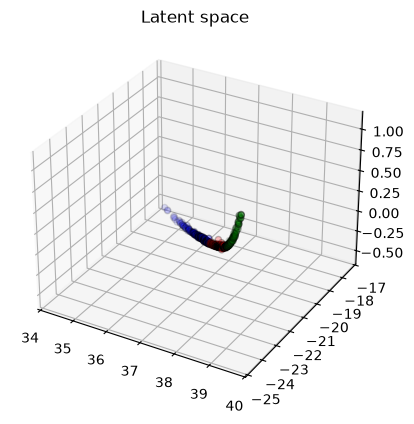

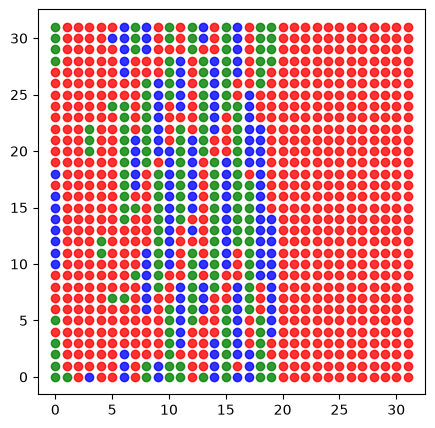

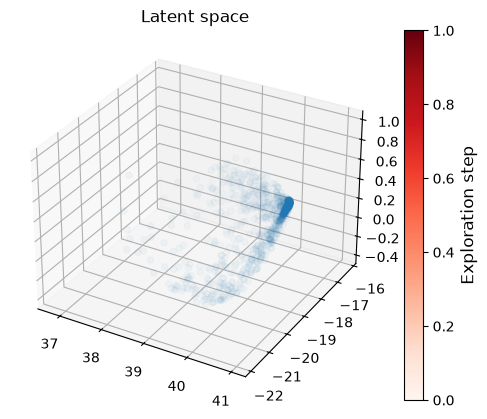

(1024,)


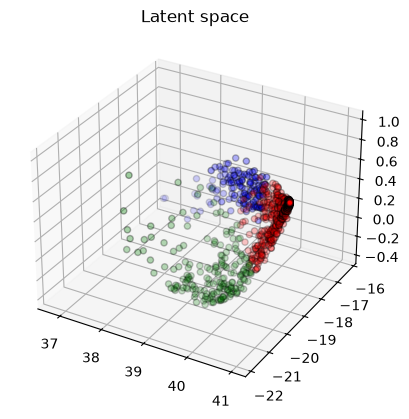

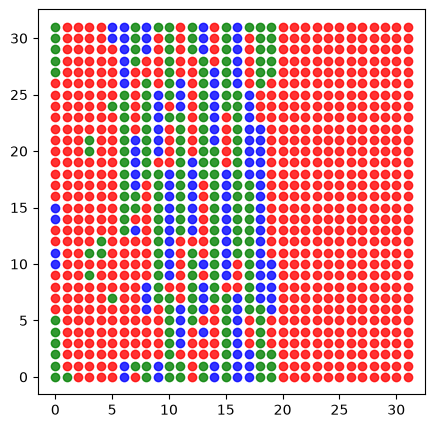

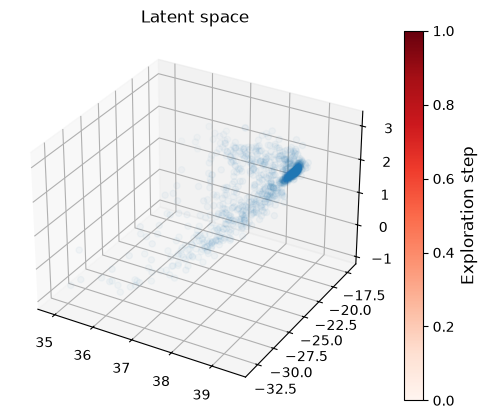

(1024,)


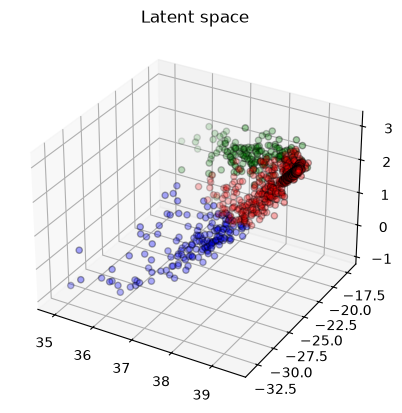

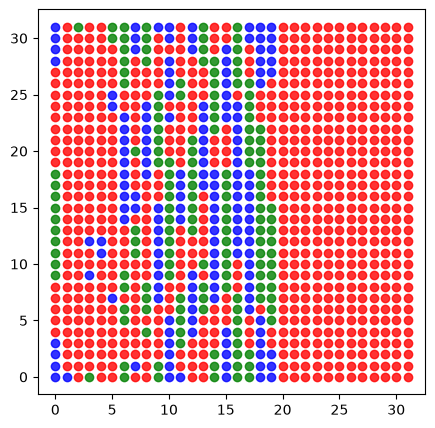

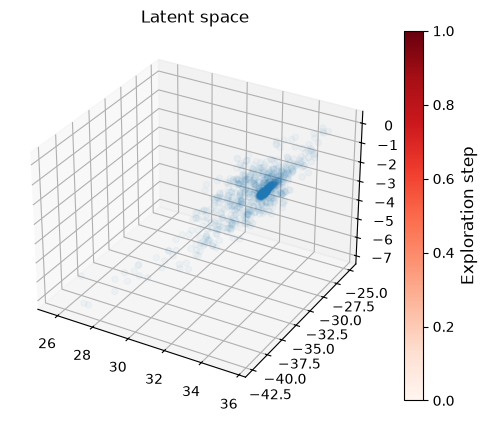

(1024,)


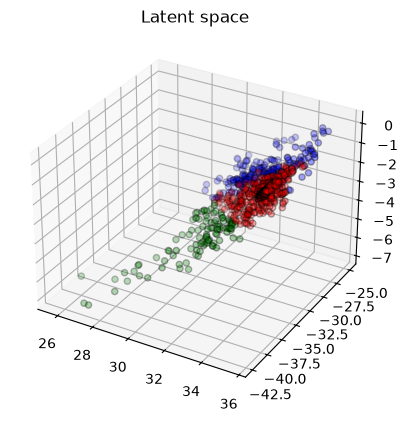

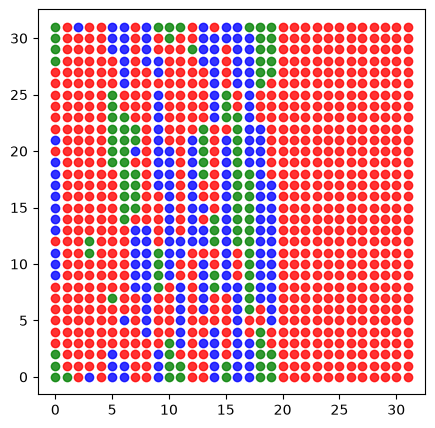

In [49]:
# Call the new plotting function
plot_scale_specific_error_and_acquisition_maps(scale_coordinates, predicted_errors, aq_fn)

unique_scales = np.unique(scale_coordinates[:, 2])
for s in unique_scales[::2]:
  scale_mask = scale_coordinates[:, 2] == s
  latent_space_scaled = posterior_spectra[scale_mask]

  # Latent space plot
  plot_latent_space(latent_space_scaled, posterior_trainset[initial_trainsize:], lat_order = [0,1,2])

  # Clustered latent space plot
  cluster_latent_space(latent_space_scaled, lat_order = [0, 1, 2], n_clusters = 3)


# Variance with test size

In [50]:
def split_augment(train_size, random_state = 42):

  images_train, images_test, spectra_train, spectra_test, s_coords_train, s_coords_test = train_test_split(
  images_all, spectra_all, swap_coordinates_all, train_size = train_size, random_state=42)



  images_tr_aug, spectra_tr_aug, _ = append_multiscale_data(images_train, spectra_train, scales=np.arange(WS_init, WS, d_WS),
                                                              coordinates=s_coords_train,
                                                              append_image_type=append_image_type)



  images_test_aug, spectra_test_aug, _ = append_multiscale_data(images_test, spectra_test, scales=np.arange(WS_init, WS, d_WS),
                                                              coordinates=s_coords_test,
                                                              append_image_type=append_image_type)

  return images_tr_aug, images_test_aug, spectra_tr_aug, spectra_test_aug


Testing with test size: 0.1
Augmented images shape: (816, 32, 32), Augmented spectra shape: (816, 121), Augmented coordinates shape: (816, 3)
Augmented images shape: (7376, 32, 32), Augmented spectra shape: (7376, 121), Augmented coordinates shape: (7376, 3)


100%|██████████| 5/5 [02:55<00:00, 35.19s/it, train_loss=0.0021, val_loss=0.0023]

SWA triggered at epoch 4


  Error targets train shape: (816, 1)
  Error targets test shape: (7376, 1)


100%|██████████| 5/5 [00:22<00:00,  4.53s/it, train_loss=0.0001, val_loss=0.0001]

SWA triggered at epoch 4


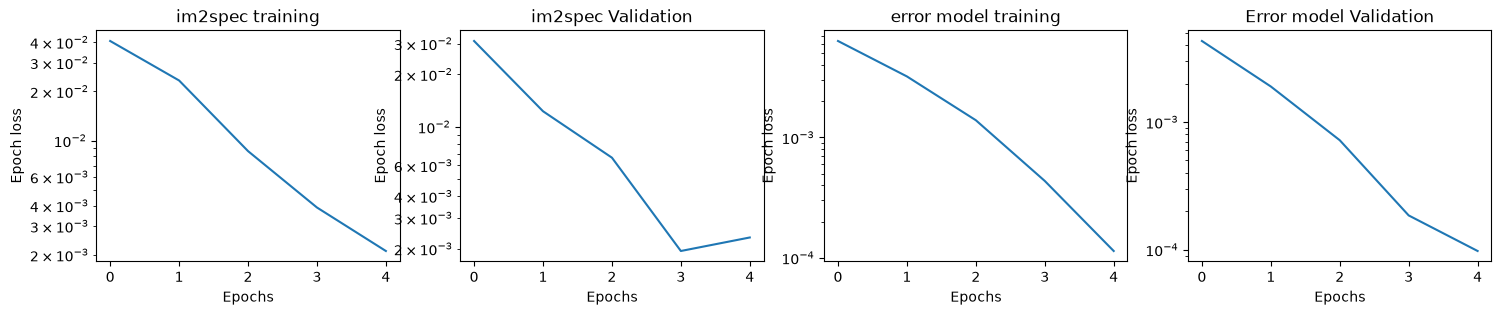


Testing with test size: 0.4
Augmented images shape: (3272, 32, 32), Augmented spectra shape: (3272, 121), Augmented coordinates shape: (3272, 3)
Augmented images shape: (4920, 32, 32), Augmented spectra shape: (4920, 121), Augmented coordinates shape: (4920, 3)


100%|██████████| 5/5 [03:00<00:00, 36.09s/it, train_loss=0.0027, val_loss=0.0021]

SWA triggered at epoch 4


  Error targets train shape: (3272, 1)
  Error targets test shape: (4920, 1)


100%|██████████| 5/5 [01:29<00:00, 17.99s/it, train_loss=0.0001, val_loss=0.0001]

SWA triggered at epoch 4


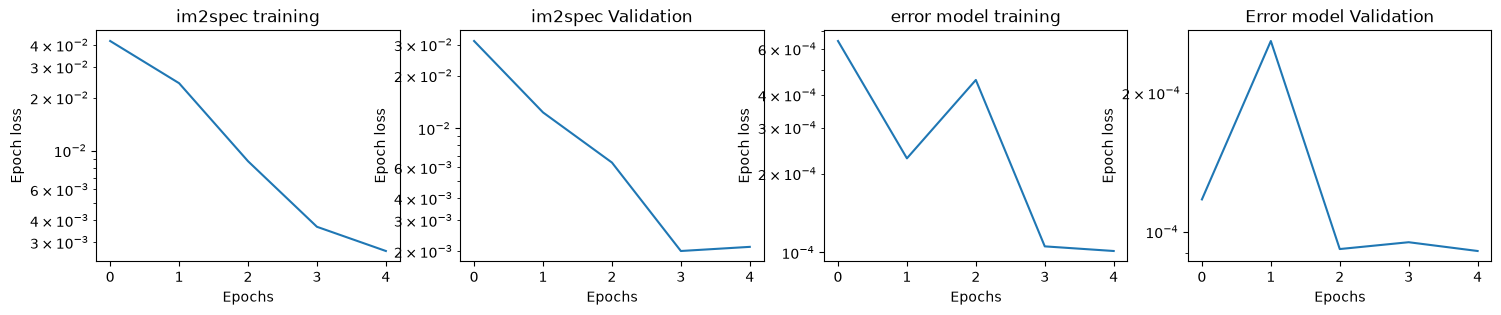


Testing with test size: 0.7000000000000001
Augmented images shape: (5728, 32, 32), Augmented spectra shape: (5728, 121), Augmented coordinates shape: (5728, 3)
Augmented images shape: (2464, 32, 32), Augmented spectra shape: (2464, 121), Augmented coordinates shape: (2464, 3)


100%|██████████| 5/5 [04:17<00:00, 51.59s/it, train_loss=0.0023, val_loss=0.0020]

SWA triggered at epoch 4


  Error targets train shape: (5728, 1)
  Error targets test shape: (2464, 1)


100%|██████████| 5/5 [03:04<00:00, 36.83s/it, train_loss=0.0427, val_loss=0.0361]

SWA triggered at epoch 4


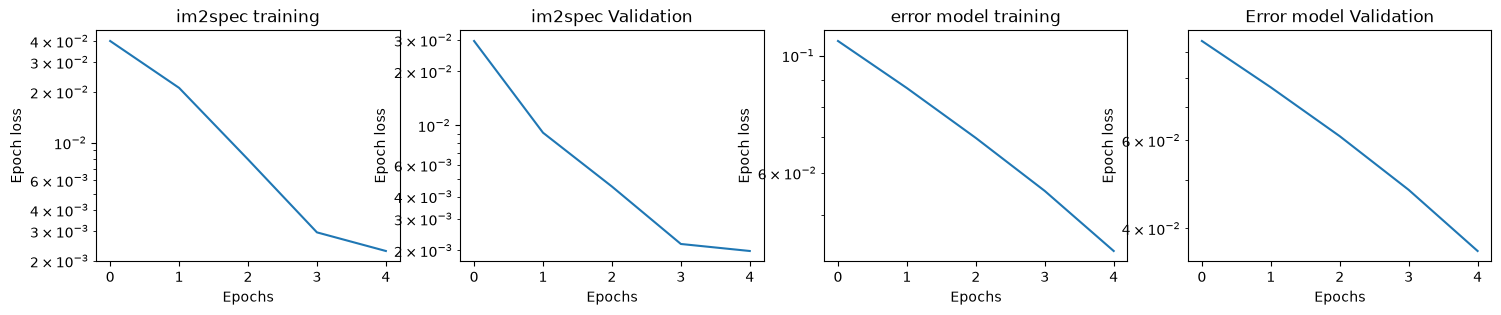

In [51]:
train_sizes = np.arange(0.1, 1, 0.3)

im2spec_train_losses = []
im2spec_val_losses = []
im2spec_test_losses = []

error_train_losses = []
error_val_losses = []
error_test_losses = []

for ts in train_sizes:



    print(f"\nTesting with test size: {ts}")

    #original_images, original_spectra, original_coordinates = paired_images_spectra_1(full_image, cits_obj, hyperspectra, window_size = WS, coordinate_step = 15, image_norm=False, spectra_norm = False)
    images_train_ts, images_test_ts, spectra_train_ts, spectra_test_ts = split_augment(ts)


    if images_train_ts.shape[0] == 0 or images_test_ts.shape[0] == 0:
        print(f"Skipping test size {ts} due to insufficient training data.")
        continue

    # Train im2spec model on this train/test split
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    imspec_model_ts = FNO_im2spec(
        target_size=out_dim,
        latent_dim=3,
        hidden_channels=32,
        n_modes=(16, 16),
        n_layers=4,
    ).to(device)

    #imspec_model_ts = im2spec(feature_size=in_dim, target_size=out_dim, latent_dim=3).to(device)

    impsec_training_dataset_ts = TensorDataset(
        torch.tensor(images_train_ts, dtype=torch.float32),
        torch.tensor(spectra_train_ts, dtype=torch.float32),
    )
    impsec_val_dataset_ts = TensorDataset(
        torch.tensor(images_test_ts, dtype=torch.float32),
        torch.tensor(spectra_test_ts, dtype=torch.float32),
    )

    im2spec_model_ts, im2spec_train_loss_ts, im2spec_val_loss_ts = train_model(
        imspec_model_ts,
        impsec_training_dataset_ts,
        n_batches=6,
        lr=1e-3,
        patience=10,
        n_epochs=n_epochs_error,
        partial_train= False,
        val_dataset = impsec_val_dataset_ts,
        use_swa = True,
        last_swa_epochs = 0.1
    )


    im2spec_train_losses.append(im2spec_train_loss_ts)
    im2spec_val_losses.append(im2spec_val_loss_ts)

    imspec_model_ts.eval()
    with torch.no_grad():
        x_test_ts = torch.tensor(images_test_ts, dtype=torch.float32, device=device)
        y_test_ts = torch.tensor(spectra_test_ts, dtype=torch.float32, device=device)
        test_pred_ts = imspec_model_ts.predict(x_test_ts)
        im2spec_test_loss_ts = torch.nn.functional.mse_loss(test_pred_ts, y_test_ts).item()
    im2spec_test_losses.append(im2spec_test_loss_ts)

    # Train error model
    error_mean_ts, _, _ = err_estimation(imspec_model_ts, images_train_ts, spectra_train_ts, error_type=error_type)
    error_targets_ts = error_mean_ts.astype(np.float32).reshape(-1, 1)

    # Add error estimation for the test set
    error_mean_test_ts, _, _ = err_estimation(imspec_model_ts, images_test_ts, spectra_test_ts, error_type=error_type)
    error_targets_test_ts = error_mean_test_ts.astype(np.float32).reshape(-1, 1)

    print(f"  Error targets train shape: {error_targets_ts.shape}")
    print(f"  Error targets test shape: {error_targets_test_ts.shape}")

    latent_dim_ts = imspec_model_ts.encoder(torch.tensor(images[:1], dtype=torch.float32, device=device).unsqueeze(1)).shape[1]
    error_model_ts = CustomDecoder(encoder=imspec_model_ts.encoder, embed_dim=latent_dim_ts, target_size=1).to(device)

    error_training_dataset_ts = TensorDataset(
        torch.tensor(images_train_ts, dtype=torch.float32),
        torch.tensor(error_targets_ts, dtype=torch.float32),
    )

    error_model_ts, error_train_loss_ts, error_val_loss_ts = train_model(
        error_model_ts,
        error_training_dataset_ts,
        n_batches=6,
        lr=1e-3,
        patience=10,
        n_epochs=n_epochs_error,
        partial_train=True,
        use_swa = True,
        last_swa_epochs = 0.1
    )

    plot_training_loss([im2spec_train_loss_ts], [im2spec_val_loss_ts], error_train_loss_ts, error_val_loss_ts)

    # Append all losses to the lists for box plotting
    error_train_losses.append(error_train_loss_ts)
    error_test_losses.append(error_mean_test_ts)
    error_val_losses.append(error_val_loss_ts)

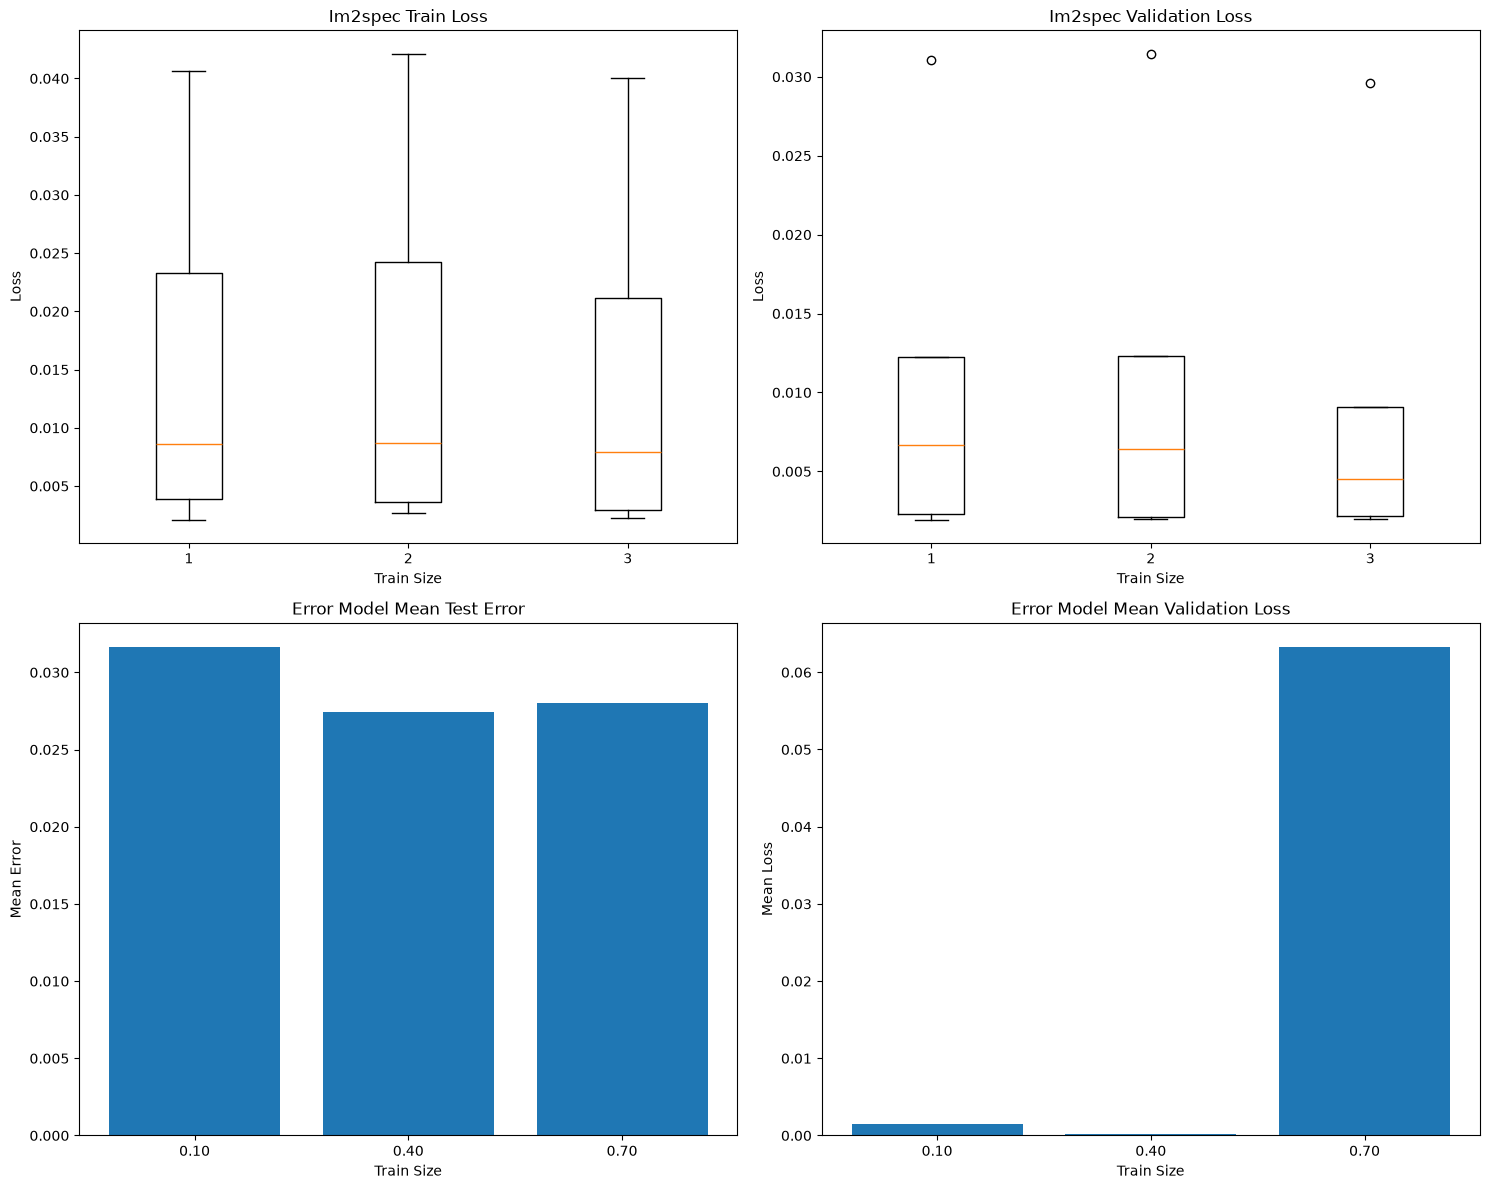

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate the mean validation loss for the error model for bar plotting
mean_error_val_losses = [np.mean(losses) for losses in error_val_losses]

# Calculate mean of error_test_losses for bar plotting
mean_error_test_losses_per_train_size = [np.mean(err_arr) for err_arr in error_test_losses]

# Plot charts on a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Im2spec Train Loss Box Plot
axes[0, 0].boxplot(im2spec_train_losses)
axes[0, 0].set_title("Im2spec Train Loss")
axes[0, 0].set_xlabel("Train Size")
axes[0, 0].set_ylabel("Loss")

# Im2spec Validation Loss Box Plot
axes[0, 1].boxplot(im2spec_val_losses)
axes[0, 1].set_title("Im2spec Validation Loss")
axes[0, 1].set_xlabel("Train Size")
axes[0, 1].set_ylabel("Loss")

# Error Model Mean Test Error Bar Chart
axes[1, 0].bar([f"{ts:.2f}" for ts in train_sizes], mean_error_test_losses_per_train_size)
axes[1, 0].set_title("Error Model Mean Test Error")
axes[1, 0].set_xlabel("Train Size")
axes[1, 0].set_ylabel("Mean Error")

# Error Model Mean Validation Loss Bar Chart
axes[1, 1].bar([f"{ts:.2f}" for ts in train_sizes], mean_error_val_losses)
axes[1, 1].set_title("Error Model Mean Validation Loss")
axes[1, 1].set_xlabel("Train Size")
axes[1, 1].set_ylabel("Mean Loss")

plt.tight_layout()
plt.show()

# Acquisition Function

In [60]:
import pandas as pd

# grouping
df_errors = pd.DataFrame({
    'x': scale_coordinates[:, 0],
    'y': scale_coordinates[:, 1],
    'scale': scale_coordinates[:, 2],
    'error': predicted_errors,
    'original_index': np.arange(len(predicted_errors)) # Store original indices
})

# x,y grouping by error
# idx min gets the index of the points with min error in the scale
# then get full row with x and y coords.
min_errors_df = df_errors.loc[df_errors.groupby(['x', 'y'])['error'].idxmin()].reset_index(drop=True)

# relevant columns, including the original_index for mapping back
min_errors_xy = min_errors_df[['x', 'y', 'scale','error', 'original_index']]

print("Minimum error for each (x, y) coordinate:")
display(min_errors_xy.head())

print("Shape of min_errors_xy (x, y, min_error, original_index):")
print(min_errors_xy.shape)

Minimum error for each (x, y) coordinate:


,x,y,scale,error,original_index
0,30.0,30.0,4.0,0.0,0
1,30.0,45.0,4.0,0.0,32
2,30.0,60.0,4.0,0.0,64
3,30.0,75.0,4.0,0.0,96
4,30.0,90.0,4.0,0.0,128


Shape of min_errors_xy (x, y, min_error, original_index):
(1024, 5)


In [56]:
# Calculate aq_fn for the entire dataset based on min_errors_xy
from nnerror.training_functions import distance_acq_fn

aq_ind, aq_fn = distance_acq_fn(min_errors_xy['error'].values,
                                beta=0,
                                lambda_=1,
                                sample_next_points=len(min_errors_xy), # Get values for all
                                exclude_indices=[])
print("Shape of aq_fn:", aq_fn.shape)


Shape of aq_fn: (1024,)


/Users/8ij/nnerror/NN_Error/src/nnerror/training_functions.py:23: RuntimeWarning: invalid value encountered in divide
  arr = (arr - arr.min()) / (arr.max() - arr.min())


In [58]:
from nnerror.training_functions import distance_acq_fn, append_training_set, train_model, err_estimation, predict_spectra
from nnerror.plot_functions import plot_error_prediction, plot_spectra, plot_error_prediction_3d
from nnerror.networks import CustomDecoder # Assuming CustomDecoder is needed for error_model retraining
from sklearn.model_selection import train_test_split # Added import for train_test_split


#al denotes variables used for active learning

# initialize variables for the acquisition loop
acquisition_iterations = 5  # number of iterations
num_new_points = 10  # points per iteration

error_log = [] # reinitialize error_log for tracking

# storing losses
im2spec_al_train_losses = []
im2spec_al_val_losses = []
error_al_train_losses = []
error_al_val_losses = []


# original indices for the full dataset
original_indices = np.arange(len(images))

# aqn function for all available x,y locations
_, initial_aq_fn_values_all = distance_acq_fn(min_errors_xy['error'].values,
                                                beta=0,
                                                lambda_=1,
                                                sample_next_points=len(min_errors_xy), # Get values for all
                                                exclude_indices=[])

# initialize training set as empty array
current_images_train = np.empty((0, images.shape[1], images.shape[2]), dtype=images.dtype)
current_spectra_train = np.empty((0, spectra.shape[1]), dtype=spectra.dtype)
current_indices_train = np.empty((0,), dtype=np.int64)

#redo test train split to ensure there is something in the train set initially

#all available original indices
all_available_indices = min_errors_xy['original_index'].values

#
initial_train_indices, _ = train_test_split(
    all_available_indices, test_size=0.9, random_state=42
)

for next_index in initial_train_indices:
    current_images_train, current_spectra_train, current_indices_train = append_training_set(
        images, spectra, next_index, current_images_train, current_spectra_train, current_indices_train
    )


for i in range(acquisition_iterations):
    print(f"\nActive Learning Iteration {i+1}/{acquisition_iterations}")

    # ensuring that the same point does not get selected
    # filter out points whose original_index is already in current_indices_train
    available_min_errors_xy = min_errors_xy[~min_errors_xy['original_index'].isin(current_indices_train)]

    if len(available_min_errors_xy) == 0:
        print(f"No more points to acquire after {i} iterations.")
        break

    aq_ind_df, _ = distance_acq_fn(available_min_errors_xy['error'].values,
                                            beta=0,
                                            lambda_=1,
                                            sample_next_points=num_new_points,
                                            exclude_indices=[])

    # get original indices of the new points
    newly_acquired_original_indices = available_min_errors_xy.iloc[aq_ind_df]['original_index'].values

    # use the append_training_set function for each newly acquired point
    for next_index in newly_acquired_original_indices:
        current_images_train, current_spectra_train, current_indices_train = append_training_set(
            images, spectra, next_index, current_images_train, current_spectra_train, current_indices_train
        )

    # error of new points for logging
    new_images = images[newly_acquired_original_indices]
    new_spectra = spectra[newly_acquired_original_indices]

    error_mean_new_points, _, _ = err_estimation(imspec_model, new_images, new_spectra, error_type=error_type)
    error_log.append(error_mean_new_points.mean())


    # recreate datasets
    im2spec_al_training_dataset = TensorDataset(
        torch.tensor(current_images_train, dtype=torch.float32),
        torch.tensor(current_spectra_train, dtype=torch.float32),
    )

    # validation dataset
    im2spec_al_val_dataset = TensorDataset(
        torch.tensor(images_test_aug, dtype=torch.float32),
        torch.tensor(spectra_test_aug, dtype=torch.float32),
    )

    # retrain imspec_model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if model_type == 'FNO':
        imspec_model = FNO_im2spec(
            target_size=out_dim,
            latent_dim=3,
            hidden_channels=32,
            n_modes=(16, 16),
            n_layers=4,
        ).to(device)
    elif model_type == 'im2spec':
        imspec_model = im2spec(feature_size=in_dim, target_size=out_dim, latent_dim=3).to(device)
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    imspec_model, al_im2spec_train_loss, al_im2spec_val_loss = train_model(
        imspec_model,
        im2spec_al_training_dataset,
        n_batches=6,
        lr=1e-3,
        patience= 10,
        n_epochs=n_epochs_im2spec // 5, #reduced epochs for faster retraining
        partial_train=False,
        val_dataset=im2spec_al_val_dataset,
        use_swa=True,
    )
    im2spec_al_train_losses.append(al_im2spec_train_loss[-1])
    im2spec_al_val_losses.append(al_im2spec_val_loss[-1])

    # estimate errors again with the appended dataset
    error_mean_al, _, _ = err_estimation(imspec_model, current_images_train, current_spectra_train, error_type=error_type)
    error_targets_al = error_mean_al.astype(np.float32).reshape(-1, 1)

    # retrain and reinitialize error model
    with torch.no_grad():
        latent_dim = imspec_model.encoder(torch.tensor(images[:1], dtype=torch.float32, device=device).unsqueeze(1)).shape[1]
    error_model = CustomDecoder(encoder=imspec_model.encoder, embed_dim=latent_dim, target_size=1).to(device)

    error_al_training_dataset = TensorDataset(
        torch.tensor(current_images_train, dtype=torch.float32),
        torch.tensor(error_targets_al, dtype=torch.float32),
    )

    # test set errors to evaluate error model
    error_mean_test_al, _, _ = err_estimation(imspec_model, images_test_aug, spectra_test_aug, error_type=error_type)
    error_targets_test_al = error_mean_test_al.astype(np.float32).reshape(-1, 1)

    error_al_val_dataset = TensorDataset(
        torch.tensor(images_test_aug, dtype=torch.float32),
        torch.tensor(error_targets_test_al, dtype=torch.float32),
    )

    error_model, al_error_train_loss, al_error_val_loss = train_model(
        error_model,
        error_al_training_dataset,
        n_batches=6,
        lr=1e-3,
        patience=5,
        n_epochs=n_epochs_error // 5,
        partial_train=True,
        val_dataset=error_al_val_dataset,
    )
    error_al_train_losses.append(al_error_train_loss[-1])
    error_al_val_losses.append(al_error_val_loss[-1])


Active Learning Iteration 1/5


100%|██████████| 1/1 [00:06<00:00,  6.95s/it, train_loss=0.0375, val_loss=0.0262]

SWA triggered at epoch 0



100%|██████████| 1/1 [00:05<00:00,  5.97s/it, train_loss=0.0022, val_loss=0.4564]



Active Learning Iteration 2/5


...


100%|██████████| 1/1 [00:06<00:00,  6.46s/it, train_loss=0.1828, val_loss=0.5448]



Active Learning Iteration 5/5


100%|██████████| 1/1 [00:07<00:00,  7.07s/it, train_loss=0.0363, val_loss=0.0211]

SWA triggered at epoch 0



100%|██████████| 1/1 [00:07<00:00,  7.14s/it, train_loss=0.2025, val_loss=0.0316]


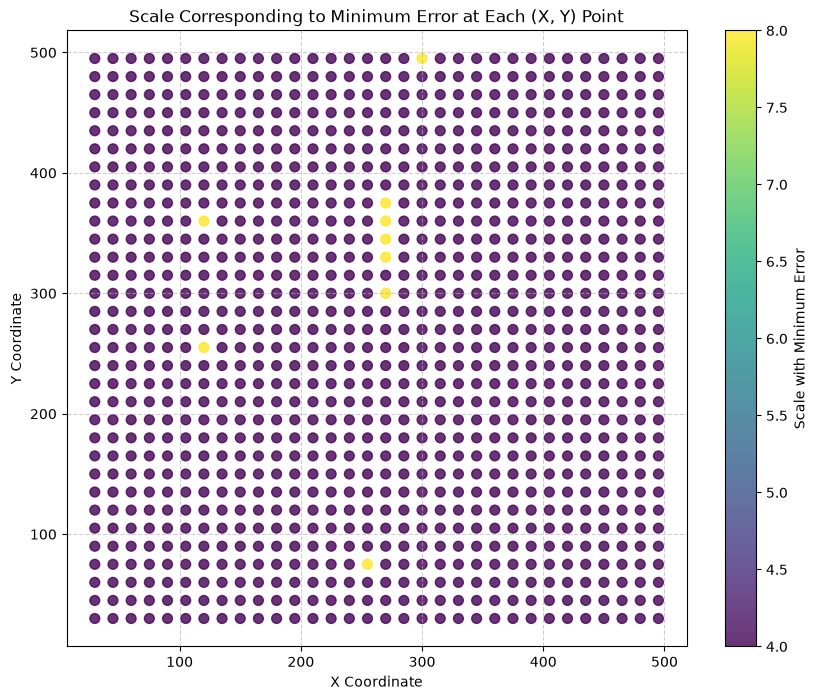

In [61]:
import matplotlib.pyplot as plt

# Visualize the scales corresponding to the minimum error for each (x, y) point
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(min_errors_xy['x'], min_errors_xy['y'], c=min_errors_xy['scale'], cmap='viridis', s=50, alpha=0.8)
cbar = fig.colorbar(scatter)
cbar.set_label('Scale with Minimum Error')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_title('Scale Corresponding to Minimum Error at Each (X, Y) Point')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()